[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/02_conditional_probability_and_bayes/first_principles.ipynb)

# Module 02 — Conditional Probability and Bayes' Theorem

## 1. Why This Module Exists

Probability is not static: it responds to information. Draw a card from a standard deck — the probability of a heart is $1/4$. Now peek and learn only that the card is red. Half of the red cards are hearts, so the number should become $1/2$. Every use of data to revise an opinion is an instance of this operation, and this module is the calculus of it.

The operation has to be *defined*, not discovered. Kolmogorov's axioms (Module 01) fix a single measure $P$ on a single sample space; they say nothing about what happens when an observer learns that an event $B$ occurred. Conditional probability is the extra definition that closes the gap, and Bayes' theorem is its most consequential corollary.

Forward models are easy to specify: given a disease, a test is positive with known probability; given a category, a document contains certain words with known frequencies. Decisions require the *reverse* direction: given the positive test, how likely is the disease? The two directions are not interchangeable — $P(\text{positive} \mid \text{disease})$ can be $0.95$ while $P(\text{disease} \mid \text{positive})$ is below $0.09$. Bayes' theorem is the exact exchange rate between them, and the prior (base rate) is the conversion factor. Ignoring it is the most consequential quantitative reasoning error in medicine, law and machine-learning evaluation alike.

In machine learning, conditioning is not one topic among many; it is the organizing principle. Classifiers model $P(y \mid \mathbf{x})$, language models factor sequence probability by the chain rule, naive Bayes and Bayesian networks are engineered conditional-independence structures, and every Bayesian method from spam filtering to variational inference is Bayes' theorem operationalized at scale.

## 2. Intuition

Conditioning is two mechanical steps:

1. **Restrict** — discard every outcome incompatible with the known event $B$.
2. **Renormalize** — rescale the surviving mass by $1/P(B)$ so that it totals $1$ again.

The formula $P(A \mid B) = P(A \cap B)/P(B)$ is nothing more than these two steps written down. Geometrically, if probability is area, then $P(A \mid B)$ is *the fraction of $B$'s area that $A$ occupies*. Renormalization is a pure rescaling, so it never changes the relative proportions of outcomes inside $B$ — which is exactly why every identity of unconditional probability survives conditioning unchanged (Theorem 4.1).

Two consequences of the picture are worth holding on to before any algebra:

- **Conditioning can move a probability in either direction.** $P(A \mid B)$ exceeds $P(A)$ when $A$ occupies a larger share of $B$ than of $\Omega$, and falls below it otherwise. Evidence is not "positive" or "negative" in the abstract; it is a comparison of two area fractions.
- **The observation is an event, not a fact.** "The host opened door 3" is a different event from "door 3 hides a goat", and they carry different areas. Most probability paradoxes are the same mistake: conditioning on the content of a message instead of on the mechanism that produced it.

The setup cell below fixes the plotting style and the single random generator used by every later cell; the figure that follows draws the restrict-and-renormalize picture with exact areas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy.special import logsumexp, softmax

Figure 1 takes $\Omega = [0,1]^2$ with the uniform (area) measure, $A = [0.1, 0.7] \times [0.2, 0.9]$ and $B = [0.4, 1.0] \times [0.0, 0.6]$. The left panel is the unrestricted space; the right panel is $B$ rescaled to unit size, which is literally the renormalization step.

P(A) = 0.4200   P(B) = 0.3600   P(A and B) = 0.1200
P(A | B) = 0.3333   (exact value 1/3 = 0.3333)


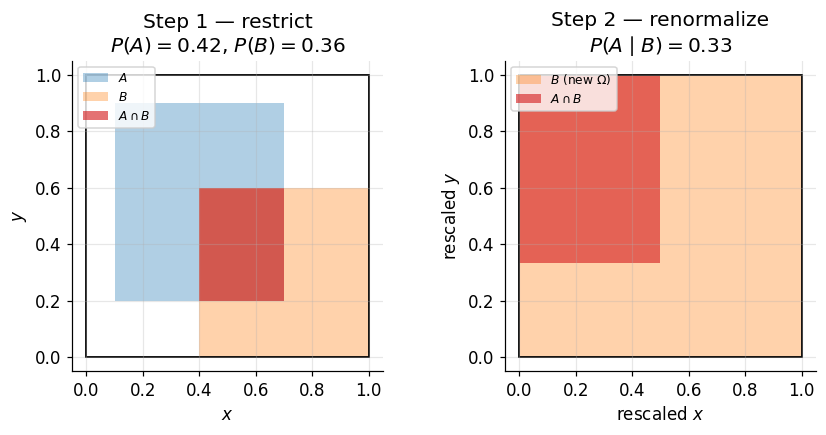

In [2]:
# Figure 1: conditioning = restrict to B, then renormalize.
from matplotlib.patches import Rectangle

A = (0.1, 0.2, 0.6, 0.7)   # (x0, y0, width, height)
B = (0.4, 0.0, 0.6, 0.6)
Ax0, Ay0, Aw, Ah = A
Bx0, By0, Bw, Bh = B
ix0, iy0 = max(Ax0, Bx0), max(Ay0, By0)
ix1, iy1 = min(Ax0 + Aw, Bx0 + Bw), min(Ay0 + Ah, By0 + Bh)

P_A = Aw * Ah
P_B = Bw * Bh
P_AB = (ix1 - ix0) * (iy1 - iy0)
print(f"P(A) = {P_A:.4f}   P(B) = {P_B:.4f}   P(A and B) = {P_AB:.4f}")
print(f"P(A | B) = {P_AB / P_B:.4f}   (exact value 1/3 = {1/3:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.9))
ax = axes[0]
ax.add_patch(Rectangle((Ax0, Ay0), Aw, Ah, facecolor="tab:blue", alpha=0.35, label="$A$"))
ax.add_patch(Rectangle((Bx0, By0), Bw, Bh, facecolor="tab:orange", alpha=0.35, label="$B$"))
ax.add_patch(Rectangle((ix0, iy0), ix1 - ix0, iy1 - iy0, facecolor="tab:red",
                       alpha=0.65, label=r"$A \cap B$"))
ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", linewidth=1.2))
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title(f"Step 1 — restrict\n$P(A)={P_A:.2f}$, $P(B)={P_B:.2f}$")
ax.legend(loc="upper left", fontsize=8)

ax = axes[1]
ax.add_patch(Rectangle((0, 0), 1, 1, facecolor="tab:orange", alpha=0.35, label="$B$ (new $\\Omega$)"))
ax.add_patch(Rectangle(((ix0 - Bx0) / Bw, (iy0 - By0) / Bh),
                       (ix1 - ix0) / Bw, (iy1 - iy0) / Bh,
                       facecolor="tab:red", alpha=0.65, label=r"$A \cap B$"))
ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", linewidth=1.2))
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.set_xlabel("rescaled $x$"); ax.set_ylabel("rescaled $y$")
ax.set_title(f"Step 2 — renormalize\n$P(A \\mid B)={P_AB / P_B:.2f}$")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

The unconditional probability of $A$ is $0.42$, yet inside $B$ it is only $1/3$: conditioning on $B$ *lowered* the probability of $A$, because $A$ covers a smaller share of $B$ than of $\Omega$. The right panel carries no new information — it is the left panel's $B$ blown up by $1/P(B)$ — which is the visual statement that renormalization preserves ratios.

## 3. Definitions

Throughout, $(\Omega, \mathcal{F}, P)$ is a probability space in the sense of Module 01.

### Definition 3.1 (Conditional Probability)

For events $A, B \in \mathcal{F}$ with $P(B) \gt 0$,

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}.
$$

The hypothesis $P(B) \gt 0$ is part of the definition, not a technicality: for $P(B) = 0$ the ratio is $0/0$ and no consistent value can be assigned without extra structure (Problem L3.3).

### Definition 3.2 (Partition)

A finite or countable family $\{B_i\}_{i \in I} \subseteq \mathcal{F}$ is a *partition* of $\Omega$ if the $B_i$ are pairwise disjoint, $\bigcup_{i \in I} B_i = \Omega$, and $P(B_i) \gt 0$ for every $i$.

### Definition 3.3 (Independence)

Events $A$ and $B$ are *independent*, written $A \perp\!\!\!\perp B$, iff

$$
P(A \cap B) = P(A)\,P(B).
$$

Equivalently, when $P(B) \gt 0$: $P(A \mid B) = P(A)$. A family $\{A_i\}_{i \in I}$ is *mutually independent* if $P\left(\bigcap_{i \in J} A_i\right) = \prod_{i \in J} P(A_i)$ for **every** finite $J \subseteq I$ — strictly stronger than pairwise independence (Problem L1.4).

### Definition 3.4 (Conditional Independence)

For $P(C) \gt 0$, events $A$ and $B$ are *conditionally independent given $C$*, written $A \perp\!\!\!\perp B \mid C$, iff

$$
P(A \cap B \mid C) = P(A \mid C)\,P(B \mid C).
$$

Neither independence nor conditional independence implies the other; Proposition 4.7 gives one direction and Example 6.4 gives the other.

### Definition 3.5 (Odds and Bayes Factor)

For an event $H$ with $0 \lt P(H) \lt 1$, the *odds* of $H$ are $O(H) = P(H)/P(H^c)$, and the *Bayes factor* of evidence $D$ (with $P(D \mid H^c) \gt 0$) is the likelihood ratio

$$
\operatorname{BF}(D) = \frac{P(D \mid H)}{P(D \mid H^c)}.
$$

The *log-odds* (logit) is $\operatorname{logit}(p) = \log\frac{p}{1-p}$, whose inverse is the logistic sigmoid $\sigma(z) = 1/(1 + e^{-z})$.

## 4. Main Results

### Theorem 4.1 (Conditioning Yields a Probability Measure)

Let $B \in \mathcal{F}$ with $P(B) \gt 0$. Then $Q(A) = P(A \mid B)$ defines a probability measure on $(\Omega, \mathcal{F})$, and $Q(B) = 1$.

*Hypothesis.* $P(B) \gt 0$ is needed because $Q$ divides by $P(B)$; with $P(B) = 0$ the map is undefined rather than merely degenerate.

$$
\boxed{\;A \mapsto P(A \mid B)\ \text{is a probability measure on }(\Omega,\mathcal{F})\;}
$$

**Interpretation.** Conditioning does not create a new kind of object: the conditioned world is an ordinary probability space whose sample space has effectively shrunk to $B$. The consequence is that every theorem of Module 01 — complement rule, monotonicity, inclusion–exclusion, union bound, continuity along monotone sequences — can be applied verbatim with a $\mid B$ appended to every probability. In practice this is what licenses statements such as $P(A \mid B) + P(A^c \mid B) = 1$, and it is why a pipeline reporting $0.5$ and $0.6$ for those two numbers has a bug (Problem L0.4).

### Theorem 4.2 (Chain Rule)

Let $A_1, \ldots, A_n \in \mathcal{F}$ with $P(A_1 \cap \cdots \cap A_{n-1}) \gt 0$. Then

$$
\boxed{\;P(A_1 \cap \cdots \cap A_n) = P(A_1)\,P(A_2 \mid A_1)\,P(A_3 \mid A_1 \cap A_2)\cdots P(A_n \mid A_1 \cap \cdots \cap A_{n-1})\;}
$$

*Hypothesis.* $P(A_1 \cap \cdots \cap A_{n-1}) \gt 0$ is needed so that every conditioning event on the right has positive probability; by monotonicity it forces $P(A_1 \cap \cdots \cap A_k) \gt 0$ for all $k \le n-1$, so no factor is undefined.

**Interpretation.** Any joint distribution over $n$ objects factors into $n$ one-step conditionals, in any order chosen in advance. The consequence is architectural: an autoregressive language model is exactly this factorization, $P(w_1, \ldots, w_T) = \prod_t P(w_t \mid w_{\lt t})$, with a neural network supplying each factor, and the cross-entropy training loss is the negative logarithm of the product.

### Theorem 4.3 (Law of Total Probability)

Let $\{B_i\}_{i \in I}$ be a finite or countable partition of $\Omega$ in the sense of Definition 3.2. Then for every $A \in \mathcal{F}$,

$$
\boxed{\;P(A) = \sum_{i \in I} P(A \mid B_i)\,P(B_i)\;}
$$

*Hypotheses.* Pairwise disjointness is needed so that countable additivity applies to the pieces $A \cap B_i$ without double counting; exhaustiveness ($\bigcup_i B_i = \Omega$) is needed so the pieces reconstruct all of $A$; $P(B_i) \gt 0$ is needed so each conditional factor is defined. Dropping disjointness or exhaustiveness makes the identity false, as the counterexample cell in Section 7 shows numerically.

**Interpretation.** An unconditional probability is a weighted average of conditional ones, with the partition's probabilities as weights. The consequence is that marginalizing over a hidden cause is just averaging: $P(A) = \sum_i P(A \mid B_i) P(B_i)$ is the discrete prototype of $p(x) = \int p(x \mid z)\,p(z)\,dz$ in every latent-variable model, and the countable version covers hidden states ranging over an infinite set.

### Theorem 4.4 (Bayes' Theorem)

Let $\{B_i\}_{i \in I}$ be a finite or countable partition of $\Omega$ and let $A \in \mathcal{F}$ satisfy $P(A) \gt 0$. Then for every $j \in I$,

$$
\boxed{\;P(B_j \mid A) = \frac{P(A \mid B_j)\,P(B_j)}{\sum_{i \in I} P(A \mid B_i)\,P(B_i)}\;}
$$

*Hypotheses.* $P(A) \gt 0$ is needed because the left-hand side conditions on $A$ (Definition 3.1); the partition hypotheses are needed only to expand the denominator by Theorem 4.3 — without them the identity $P(B_j \mid A) = P(A \mid B_j) P(B_j)/P(A)$ still holds, but $P(A)$ must be supplied some other way.

**Interpretation.** The theorem reverses the direction of conditioning: it converts the likelihood $P(A \mid B_j)$, which a forward model supplies, into the posterior $P(B_j \mid A)$, which a decision needs. Its consequence is quantitative, not merely philosophical — the posterior is the likelihood *reweighted by the prior and renormalized*, so a large likelihood attached to a tiny prior can still yield a small posterior. That single sentence is the whole content of the base-rate fallacy (Example 6.2).

The standard names: $P(B_j)$ is the **prior**, $P(A \mid B_j)$ the **likelihood**, $P(A)$ the **evidence** (marginal likelihood), and $P(B_j \mid A)$ the **posterior**. In parameter notation, $P(\theta \mid \mathcal{D}) \propto P(\mathcal{D} \mid \theta)\,P(\theta)$.

### Corollary 4.5 (Odds Form)

Let $H \in \mathcal{F}$ with $0 \lt P(H) \lt 1$ and let $D \in \mathcal{F}$ with $P(D \mid H^c) \gt 0$ and $P(D) \gt 0$. Then

$$
\boxed{\;\underbrace{\frac{P(H \mid D)}{P(H^c \mid D)}}_{\text{posterior odds}} \;=\; \underbrace{\frac{P(D \mid H)}{P(D \mid H^c)}}_{\text{Bayes factor}} \;\times\; \underbrace{\frac{P(H)}{P(H^c)}}_{\text{prior odds}}\;}
$$

*Hypotheses.* $0 \lt P(H) \lt 1$ is needed for the odds to be finite and nonzero; $P(D \mid H^c) \gt 0$ is needed for the Bayes factor to be finite (evidence impossible under $H^c$ sends the posterior odds to infinity, which is correct but not expressible as a ratio).

**Interpretation.** In odds form the evidence term is *separated* from the prior, and the normalizing constant $P(D)$ has cancelled. The consequence is that independent pieces of evidence multiply their Bayes factors and *add* their log-Bayes-factors: sequential updating becomes accumulation of additive scores, which is why logistic regression outputs log-odds, why naive Bayes is a linear classifier in log space, and why sequential probability ratio tests sum log-likelihood ratios.

### Proposition 4.6 (Bayes' Theorem for Densities)

Let $(\Theta, X)$ have a joint density $f(\theta, x)$ that is continuous in $x$, with marginal $f_X(x) = \int f(\theta, x)\,d\theta \gt 0$ at the observed value $x$. Then the limit of $P(\Theta \in S \mid x \lt X \le x + h)$ as $h \downarrow 0$ exists and equals $\int_S p(\theta \mid x)\,d\theta$ with

$$
\boxed{\;p(\theta \mid x) = \frac{p(x \mid \theta)\,p(\theta)}{\int p(x \mid \theta')\,p(\theta')\,d\theta'}\;}
$$

*Hypotheses.* Continuity in $x$ is needed to pass the limit through the integrals; $f_X(x) \gt 0$ is needed so the denominator does not vanish. Both are needed because the conditioning event $\{X = x\}$ has probability zero, so Definition 3.1 does not apply directly.

**Interpretation.** The continuous form of Bayes' theorem is not a new axiom or an analogy — it is the discrete form applied to shrinking strips, with the strip width cancelling between numerator and denominator. The consequence is a caution as well as a licence: the limit is only well defined *relative to the family of shrinking events chosen*, and different families can give different answers when the conditioning set is curved (Borel's paradox, Problem L3.3).

### Proposition 4.7 (Explaining Away: Independence Is Not Preserved by Conditioning)

Let $A, E$ be independent events with $P(A) = P(E) = p \in (0,1)$, and let $S = A \cup E$. Then $A \perp\!\!\!\perp E$ but

$$
\boxed{\;P(A \mid S \cap E) = p \;\lt\; \frac{1}{2-p} = P(A \mid S)\;}
$$

*Hypotheses.* $p \gt 0$ is needed for $P(S \cap E) \gt 0$ so both conditionals are defined; $p \lt 1$ is needed for the strict inequality (at $p = 1$ everything is certain and the two sides coincide).

**Interpretation.** Two causes that are independent a priori become dependent once their common effect is observed: learning that the earthquake happened *lowers* the probability of the burglary, because the earthquake already accounts for the alarm. The consequence is that conditional independence is a statement about a specific conditioning set, never a property of a pair of events alone — and that conditioning on a collider (or on a selection criterion, which is the same thing) manufactures correlations that do not exist in the population.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Set $Q(A) = P(A \cap B)/P(B)$, well defined since $P(B) \gt 0$.

1. *Non-negativity.* $P(A \cap B) \ge 0$ and $P(B) \gt 0$, so $Q(A) \ge 0$.
2. *Normalization.* $Q(\Omega) = P(\Omega \cap B)/P(B) = P(B)/P(B) = 1$; identically $Q(B) = P(B)/P(B) = 1$.
3. *Countable additivity.* Let $A_1, A_2, \ldots$ be pairwise disjoint. The sets $A_i \cap B$ are then pairwise disjoint, and distributivity gives $\left(\bigcup_i A_i\right) \cap B = \bigcup_i (A_i \cap B)$. Countable additivity of $P$ yields

$$
Q\left(\bigcup_i A_i\right) = \frac{P\left(\bigcup_i (A_i \cap B)\right)}{P(B)} = \frac{\sum_i P(A_i \cap B)}{P(B)} = \sum_i Q(A_i).
$$

All three Kolmogorov axioms hold, so $Q$ is a probability measure. $\blacksquare$

### Proof 5.2 (of Theorem 4.2)

By hypothesis $P(A_1 \cap \cdots \cap A_k) \gt 0$ for $k \le n - 1$, so each factor below is defined. Expand every conditional by Definition 3.1 and telescope:

$$
\prod_{k=1}^{n} \frac{P(A_1 \cap \cdots \cap A_k)}{P(A_1 \cap \cdots \cap A_{k-1})} = \frac{P(A_1)}{1} \cdot \frac{P(A_1 \cap A_2)}{P(A_1)} \cdots \frac{P(A_1 \cap \cdots \cap A_n)}{P(A_1 \cap \cdots \cap A_{n-1})} = P(A_1 \cap \cdots \cap A_n),
$$

with the convention that the empty intersection is $\Omega$, of probability $1$. Every numerator cancels the following denominator. $\blacksquare$

### Proof 5.3 (of Theorem 4.3)

Since $\bigcup_{i \in I} B_i = \Omega$, distributivity of intersection over union gives

$$
A = A \cap \Omega = A \cap \left(\bigcup_{i \in I} B_i\right) = \bigcup_{i \in I} (A \cap B_i),
$$

and the pieces $A \cap B_i$ are pairwise disjoint because the $B_i$ are. Countable additivity of $P$ (valid for finite or countable $I$) and then Definition 3.1, legitimate because $P(B_i) \gt 0$, give

$$
P(A) = \sum_{i \in I} P(A \cap B_i) = \sum_{i \in I} P(A \mid B_i)\,P(B_i). \qquad \blacksquare
$$

Every term is non-negative, so for countable $I$ the series converges absolutely and its order is irrelevant.

### Proof 5.4 (of Theorem 4.4)

The proof uses only Definition 3.1 and Theorem 4.3; it never assumes the formula it derives.

*Step 1 — the joint event factors two ways.* Fix $j$ with $P(B_j) \gt 0$ and let $P(A) \gt 0$. Definition 3.1 applied with conditioning event $A$ gives $P(B_j \cap A) = P(B_j \mid A)\,P(A)$, and applied with conditioning event $B_j$ gives $P(A \cap B_j) = P(A \mid B_j)\,P(B_j)$. The two left sides are the same set, so

$$
P(B_j \mid A)\,P(A) = P(A \mid B_j)\,P(B_j).
$$

*Step 2 — solve.* Since $P(A) \gt 0$ we may divide:

$$
P(B_j \mid A) = \frac{P(A \mid B_j)\,P(B_j)}{P(A)}.
$$

*Step 3 — expand the evidence.* The family $\{B_i\}_{i \in I}$ is a partition, so Theorem 4.3 (proved independently in Proof 5.3 from countable additivity alone) gives $P(A) = \sum_{i \in I} P(A \mid B_i) P(B_i)$. Substituting,

$$
P(B_j \mid A) = \frac{P(A \mid B_j)\,P(B_j)}{\sum_{i \in I} P(A \mid B_i)\,P(B_i)}. \qquad \blacksquare
$$

The whole theorem is one symmetry — a joint probability factors in two orders — plus the bookkeeping that computes the normalizing constant. Nothing beyond countable additivity and Definition 3.1 enters, so Bayes' theorem is a consequence of the axioms rather than an additional postulate. That the *use* of the theorem as a rule for revising belief is also forced, and not merely permitted, is a separate claim; Problem L3.4 proves it by a Dutch-book argument.

### Proof 5.5 (of Corollary 4.5)

Apply Step 2 of Proof 5.4 twice, once to $H$ and once to $H^c$ (both have positive probability, and $P(D) \gt 0$):

$$
P(H \mid D) = \frac{P(D \mid H) P(H)}{P(D)}, \qquad P(H^c \mid D) = \frac{P(D \mid H^c) P(H^c)}{P(D)}.
$$

The second right-hand side is nonzero because $P(D \mid H^c) \gt 0$ and $P(H^c) \gt 0$. Dividing, the common factor $P(D)$ cancels:

$$
\frac{P(H \mid D)}{P(H^c \mid D)} = \frac{P(D \mid H)}{P(D \mid H^c)} \cdot \frac{P(H)}{P(H^c)}. \qquad \blacksquare
$$

Taking logarithms turns the product into a sum, $\operatorname{logit} P(H \mid D) = \log \operatorname{BF}(D) + \operatorname{logit} P(H)$, which is the additive form used by every sequential updater.

### Proof 5.6 (of Proposition 4.6)

The event $\{X = x\}$ is null, so Definition 3.1 cannot be applied to it. Apply it instead to the positive-probability event $B_h = \{x \lt X \le x + h\}$, $h \gt 0$, which is legitimate because $f_X$ is continuous and $f_X(x) \gt 0$, hence $P(B_h) = \int_x^{x+h} f_X(u)\,du \gt 0$ for small $h$. For a measurable $S \subseteq \Theta$,

$$
P(\Theta \in S \mid B_h) = \frac{\int_S \int_x^{x+h} f(\theta, u)\,du\,d\theta}{\int_x^{x+h} f_X(u)\,du}.
$$

Divide numerator and denominator by $h$. By continuity of $f$ in $x$ and the fundamental theorem of calculus, $\frac{1}{h}\int_x^{x+h} f(\theta, u)\,du \to f(\theta, x)$ and $\frac{1}{h}\int_x^{x+h} f_X(u)\,du \to f_X(x) \gt 0$ as $h \downarrow 0$. Hence

$$
\lim_{h \downarrow 0} P(\Theta \in S \mid B_h) = \frac{\int_S f(\theta, x)\,d\theta}{f_X(x)} = \int_S \frac{p(x \mid \theta) p(\theta)}{\int p(x \mid \theta') p(\theta')\,d\theta'}\,d\theta,
$$

using $f(\theta, x) = p(x \mid \theta) p(\theta)$ and $f_X(x) = \int p(x \mid \theta')p(\theta')\,d\theta'$. The bracketed integrand is the claimed posterior density. $\blacksquare$

The width $h$ cancels between numerator and denominator, which is why the continuous rule looks identical to the discrete one. The cancellation depends on the strips $B_h$ shrinking to $\{X = x\}$ *in this particular way*; a different shrinking family can give a different limit when the conditioning set is a curved surface, which is Borel's paradox.

### Proof 5.7 (of Proposition 4.7)

$A \perp\!\!\!\perp E$ holds by assumption. Because $A \subseteq S$ and $E \subseteq S$, we have $A \cap S = A$ and $S \cap E = E$. Independence gives

$$
P(S) = P(A \cup E) = P(A) + P(E) - P(A)P(E) = 2p - p^2 = p(2-p) \gt 0 .
$$

Therefore

$$
P(A \mid S) = \frac{P(A \cap S)}{P(S)} = \frac{p}{p(2-p)} = \frac{1}{2-p},
$$

while, using $S \cap E = E$ and then independence,

$$
P(A \mid S \cap E) = \frac{P(A \cap E)}{P(E)} = \frac{P(A)P(E)}{P(E)} = p .
$$

For $p \in (0,1)$ we have $p(2-p) = 1 - (1-p)^2 \lt 1$; dividing this strict inequality by $2-p \gt 0$ gives $p \lt \frac{1}{2-p}$. Thus $P(A \mid S \cap E) \lt P(A \mid S)$: given $S$, the events $A$ and $E$ are dependent. $\blacksquare$

## 6. Worked Examples

Each example is computed by hand here and recomputed in the code cell that follows, which asserts agreement.

### Example 6.1 (of Theorem 4.2 — two aces without replacement)

Draw two cards without replacement from a $52$-card deck; let $A_k$ be "the $k$-th card is an ace". Then $P(A_1) = 4/52 = 1/13$ and, on the restricted space of $51$ remaining cards of which $3$ are aces, $P(A_2 \mid A_1) = 3/51 = 1/17$. The chain rule gives

$$
P(A_1 \cap A_2) = \frac{4}{52}\cdot\frac{3}{51} = \frac{12}{2652} = \frac{1}{221} \approx 0.004525 .
$$

For three aces, one more factor: $P(A_1 \cap A_2 \cap A_3) = \frac{4}{52}\cdot\frac{3}{51}\cdot\frac{2}{50} = \frac{24}{132600} = \frac{1}{5525} \approx 0.000181$. Counting gives the same number, $\binom{4}{2}/\binom{52}{2} = 6/1326 = 1/221$, which is the cross-check the code cell performs.

### Example 6.2 (of Theorems 4.3 and 4.4, and Corollary 4.5 — medical screening)

Prevalence $P(D) = 0.01$; sensitivity $P(+ \mid D) = 0.95$; specificity $P(- \mid D^c) = 0.90$, so the false-positive rate is $P(+ \mid D^c) = 0.10$. The partition is $\{D, D^c\}$, a two-outcome partition, and Theorem 4.3 gives the evidence:

$$
P(+) = 0.95 \times 0.01 + 0.10 \times 0.99 = 0.0095 + 0.0990 = 0.1085 .
$$

Theorem 4.4 gives the posterior:

$$
P(D \mid +) = \frac{0.0095}{0.1085} = \frac{95}{1085} = \frac{19}{217} \approx 0.08756 .
$$

In a population of $10{,}000$: about $100$ are diseased, of whom $95$ test positive; about $9{,}900$ are healthy, of whom $990$ test positive; among the $1085$ positives only $95$ are true. A *second* independent positive test is handled fastest in odds form (Corollary 4.5): prior odds $0.01/0.99 = 1/99$, Bayes factor $0.95/0.10 = 9.5$ per test, so after two tests the odds are $9.5^2/99 = 90.25/99 \approx 0.9116$ and

$$
P(D \mid +,+) = \frac{0.9116}{1.9116} \approx 0.4769 .
$$

Contrast a genuinely "$95\%$ accurate" test, meaning sensitivity $=$ specificity $= 0.95$: then $P(+) = 0.95 \times 0.01 + 0.05 \times 0.99 = 0.059$ and $P(D \mid +) = 0.0095/0.059 \approx 0.16102$. Accuracy alone does not determine the posterior — the specificity and the prevalence do.

### Example 6.3 (of Theorem 4.4 — Monty Hall, three hypotheses)

You pick door 1; the car is behind door $i$ with prior $P(C_i) = 1/3$; the host, who knows where the car is, must open a goat door different from your pick, choosing uniformly when he has a choice. Let $H_3$ be "the host opens door 3". The mechanism supplies the likelihoods

$$
P(H_3 \mid C_1) = \tfrac12, \qquad P(H_3 \mid C_2) = 1, \qquad P(H_3 \mid C_3) = 0 .
$$

Theorem 4.3 over the partition $\{C_1, C_2, C_3\}$ gives $P(H_3) = \tfrac12\cdot\tfrac13 + 1\cdot\tfrac13 + 0\cdot\tfrac13 = \tfrac12$, and Theorem 4.4 gives

$$
P(C_2 \mid H_3) = \frac{1 \cdot \tfrac13}{\tfrac12} = \frac{2}{3}, \qquad P(C_1 \mid H_3) = \frac{\tfrac12 \cdot \tfrac13}{\tfrac12} = \frac{1}{3}.
$$

Switching doubles the win probability. The asymmetry is entirely in the likelihoods: $C_2$ forces the host's hand, $C_1$ leaves him a free choice.

### Example 6.4 (of Proposition 4.7, and the converse direction of Definition 3.4)

*Explaining away.* Take $p = 0.1$ in Proposition 4.7: burglary $A$ and earthquake $E$ each of probability $0.1$, alarm $S = A \cup E$. Then $P(S) = 0.19$, $P(A \mid S) = 1/1.9 \approx 0.5263$, and $P(A \mid S \cap E) = 0.1$. Observing the earthquake cuts the burglary posterior by a factor of five, although $A$ and $E$ are independent to begin with.

*The other direction: conditionally independent but dependent.* Let $\Theta \in \{0.2, 0.8\}$ be an unknown coin bias with $P(\Theta = 0.2) = P(\Theta = 0.8) = 1/2$, and let $X, Y$ be two flips that are independent *given* $\Theta$. Then $X \perp\!\!\!\perp Y \mid \Theta$ by construction, but

$$
P(X = 1, Y = 1) = \tfrac12 (0.2)^2 + \tfrac12 (0.8)^2 = 0.02 + 0.32 = 0.34,
$$

while $P(X = 1) = P(Y = 1) = \tfrac12(0.2) + \tfrac12(0.8) = 0.5$, so $P(X=1)P(Y=1) = 0.25 \ne 0.34$. Observing $X = 1$ makes $\Theta = 0.8$ more likely, which raises $P(Y = 1)$ — the two flips are marginally dependent. This is exactly the naive-Bayes structure of Section 8: features are conditionally independent given the class, not independent outright.

The cell below recomputes every number in Examples 6.1–6.4 from the stated inputs and asserts agreement with the hand values printed in the markdown.

In [3]:
from math import comb

# --- Example 6.1: chain rule on a deck ---
p_two_aces = (4/52) * (3/51)
p_three_aces = (4/52) * (3/51) * (2/50)
p_two_count = comb(4, 2) / comb(52, 2)
print(f"6.1  P(two aces)   = {p_two_aces:.6f}   1/221   = {1/221:.6f}")
print(f"6.1  counting route= {p_two_count:.6f}")
print(f"6.1  P(three aces) = {p_three_aces:.8f} 1/5525  = {1/5525:.8f}")
assert abs(p_two_aces - 1/221) < 1e-15 and abs(p_two_count - 1/221) < 1e-15
assert abs(p_three_aces - 1/5525) < 1e-15

# --- Example 6.2: medical screening ---
prev, sens, spec = 0.01, 0.95, 0.90
evidence = sens * prev + (1 - spec) * (1 - prev)
posterior = sens * prev / evidence
odds2 = (prev / (1 - prev)) * (sens / (1 - spec)) ** 2
posterior2 = odds2 / (1 + odds2)
sym = 0.95 * 0.01 / (0.95 * 0.01 + 0.05 * 0.99)
print(f"6.2  P(+)          = {evidence:.4f}   (hand 0.1085)")
print(f"6.2  P(D|+)        = {posterior:.5f}  (hand 19/217 = {19/217:.5f})")
print(f"6.2  P(D|+,+)      = {posterior2:.4f}   (hand 0.4769)")
print(f"6.2  sens=spec=.95 = {sym:.5f}  (hand 0.16102)")
assert abs(evidence - 0.1085) < 1e-12 and abs(posterior - 19/217) < 1e-12
assert abs(posterior2 - 0.4769) < 1e-4 and abs(sym - 0.16102) < 1e-5

# --- Example 6.3: Monty Hall, exact Bayes over three hypotheses ---
prior_c = np.array([1/3, 1/3, 1/3])
lik_h3 = np.array([0.5, 1.0, 0.0])          # P(host opens 3 | car behind i)
joint = prior_c * lik_h3
post_c = joint / joint.sum()
print(f"6.3  P(H3) = {joint.sum():.4f}   posterior over doors = {post_c}")
assert abs(joint.sum() - 0.5) < 1e-15 and abs(post_c[1] - 2/3) < 1e-15

# --- Example 6.4: explaining away and the mixture counterexample ---
p = 0.1
P_S = 2*p - p**2
P_A_given_S = p / P_S
P_A_given_SE = p                              # since S ∩ E = E and A ⫫ E
theta = np.array([0.2, 0.8]); w = np.array([0.5, 0.5])
P_XY = float(w @ theta**2); P_X = float(w @ theta)
print(f"6.4  P(A|S) = {P_A_given_S:.4f}  P(A|S,E) = {P_A_given_SE:.4f}  (hand 0.5263, 0.1)")
print(f"6.4  P(X=1,Y=1) = {P_XY:.4f} vs P(X=1)P(Y=1) = {P_X**2:.4f}  (hand 0.34 vs 0.25)")
assert abs(P_A_given_S - 1/1.9) < 1e-15 and P_A_given_SE < P_A_given_S
assert abs(P_XY - 0.34) < 1e-15 and abs(P_X**2 - 0.25) < 1e-15
print("all Section 6 hand computations reproduced")

6.1  P(two aces)   = 0.004525   1/221   = 0.004525
6.1  counting route= 0.004525
6.1  P(three aces) = 0.00018100 1/5525  = 0.00018100
6.2  P(+)          = 0.1085   (hand 0.1085)
6.2  P(D|+)        = 0.08756  (hand 19/217 = 0.08756)
6.2  P(D|+,+)      = 0.4769   (hand 0.4769)
6.2  sens=spec=.95 = 0.16102  (hand 0.16102)
6.3  P(H3) = 0.5000   posterior over doors = [0.3333 0.6667 0.    ]
6.4  P(A|S) = 0.5263  P(A|S,E) = 0.1000  (hand 0.5263, 0.1)
6.4  P(X=1,Y=1) = 0.3400 vs P(X=1)P(Y=1) = 0.2500  (hand 0.34 vs 0.25)
all Section 6 hand computations reproduced


Every printed value matches the hand computation to the digits shown, and the assertions passed, so the arithmetic of Examples 6.1–6.4 is confirmed. Note the two numbers that are most often confused: a test with sensitivity $0.95$ and specificity $0.90$ gives a posterior of $0.0876$ at prevalence $0.01$, whereas a test that is $95\%$ accurate in both directions gives $0.1610$ — a factor of nearly two, produced entirely by the specificity.

## 7. Computational Practice

### 7.1 Identity residuals

The first check takes a random joint distribution over $3$ hypotheses and $4$ observable outcomes and verifies Theorems 4.2, 4.3 and 4.4 against the joint table they are supposed to describe. If the identities hold, the residuals should be at the level of double-precision rounding, around $10^{-16}$.

In [4]:
# (a) identity residuals for the chain rule, total probability, and Bayes
n_h, n_d = 3, 4
prior = rng.dirichlet(np.ones(n_h))                 # P(H_i)
lik = rng.dirichlet(np.ones(n_d), size=n_h)         # P(D_j | H_i), rows sum to 1
joint_hd = prior[:, None] * lik                     # P(H_i, D_j)

# Theorem 4.3: evidence from the partition {H_i}
evidence_tp = lik.T @ prior
res_total = np.abs(evidence_tp - joint_hd.sum(axis=0)).max()

# Theorem 4.4: Bayes posterior vs the posterior read off the joint table
post_bayes = (lik * prior[:, None]) / evidence_tp[None, :]
post_table = joint_hd / joint_hd.sum(axis=0, keepdims=True)
res_bayes = np.abs(post_bayes - post_table).max()

# Theorem 4.2: chain rule on four binary events from a random 2x2x2x2 joint
q = rng.dirichlet(np.ones(16)).reshape(2, 2, 2, 2)
chain = (q[1].sum()
         * (q[1, 1].sum() / q[1].sum())
         * (q[1, 1, 1].sum() / q[1, 1].sum())
         * (q[1, 1, 1, 1] / q[1, 1, 1].sum()))
res_chain = abs(chain - q[1, 1, 1, 1])

print(f"total probability residual : {res_total:.3e}")
print(f"Bayes posterior residual   : {res_bayes:.3e}")
print(f"chain rule residual        : {res_chain:.3e}")
print(f"machine epsilon            : {np.finfo(float).eps:.3e}")
assert max(res_total, res_bayes, res_chain) < 1e-12

total probability residual : 0.000e+00
Bayes posterior residual   : 0.000e+00
chain rule residual        : 0.000e+00
machine epsilon            : 2.220e-16


All three residuals print as exactly $0$ — the two sides of each identity agree to the last bit, well inside the double-precision machine epsilon $2.22 \times 10^{-16}$ that bounds any single rounding. This is what a correct identity looks like numerically; a residual of $10^{-3}$ would signal an algebra error rather than rounding.

### 7.2 Hand-rolled log-space Bayes versus the library

Posteriors over many hypotheses multiply many small likelihoods. Working in log space with the shifted accumulation $\operatorname{logsumexp}(a) = m + \log\sum_i e^{a_i - m}$, $m = \max_i a_i$, avoids underflow. The cell compares the naive product of likelihoods, a hand-rolled log-space implementation, and `scipy.special.logsumexp` / `softmax` on $2000$ Bernoulli observations.

In [5]:
# (d) hand-rolled versus library, on a sequential Bayes problem that underflows in linear space
true_p = 0.6
flips = rng.binomial(1, true_p, size=2000)
hyps = np.array([0.1, 0.3, 0.5, 0.6, 0.9])
log_prior = np.full(hyps.shape, -np.log(len(hyps)))

naive = np.exp(log_prior)                      # linear-space sequential product
for x in flips:
    naive = naive * np.where(x == 1, hyps, 1 - hyps)
print("naive linear-space unnormalized posterior:", naive, " sum =", naive.sum())

log_post_un = log_prior + (flips.sum() * np.log(hyps)
                           + (flips.size - flips.sum()) * np.log1p(-hyps))
m = log_post_un.max()
mine_lse = m + np.log(np.exp(log_post_un - m).sum())      # hand-rolled logsumexp
mine = np.exp(log_post_un - mine_lse)
lib = softmax(log_post_un)                                 # scipy
print(f"hand-rolled logsumexp = {mine_lse:.10f}   scipy = {logsumexp(log_post_un):.10f}")
print("hand-rolled posterior :", mine)
print("scipy softmax         :", lib)
print(f"max |hand - library|  : {np.abs(mine - lib).max():.3e}")
print("MAP hypothesis:", hyps[np.argmax(log_post_un)], " true p =", true_p,
      " sample mean =", flips.mean())
assert np.abs(mine - lib).max() < 1e-12
assert naive.sum() == 0.0    # the linear-space recursion has underflowed to zero

naive linear-space unnormalized posterior: [0. 0. 0. 0. 0.]  sum = 0.0
hand-rolled logsumexp = -1342.3617255255   scipy = -1342.3617255255
hand-rolled posterior : [0. 0. 0. 1. 0.]
scipy softmax         : [0. 0. 0. 1. 0.]
max |hand - library|  : 0.000e+00
MAP hypothesis: 0.6  true p = 0.6  sample mean = 0.6065


The linear-space product underflows to exactly zero for every hypothesis after $2000$ observations, so the naive normalization would evaluate $0/0$; the log-space computation returns a perfectly ordinary posterior concentrated on $p = 0.6$, and agrees with `scipy.special.softmax` to better than $10^{-12}$. This is why every practical Bayesian updater, and every softmax layer, stores log-probabilities.

### 7.3 Counterexamples: what breaks when a hypothesis is dropped

Two hypotheses are dropped in turn. First the partition hypothesis of Theorem 4.3: the family $\{B_1, B_2\}$ below overlaps, so it is not a partition, and the "law of total probability" computed from it is simply wrong. Second the tempting-but-false claim that independence survives conditioning: Proposition 4.7's alarm model is evaluated numerically over a grid of $p$.

In [6]:
# (c) counterexamples: drop the partition hypothesis; drop "independence survives conditioning"
omega = np.arange(12)                      # uniform space with 12 outcomes
P = lambda S: len(S) / len(omega)
A_set = set(range(0, 6))                   # P(A) = 1/2
B1 = set(range(0, 8))                      # overlapping "partition" ...
B2 = set(range(4, 12))                     # ... B1 and B2 share {4, 5, 6, 7}
cond = lambda X, Y: len(X & Y) / len(Y)
bogus = cond(A_set, B1) * P(B1) + cond(A_set, B2) * P(B2)
print(f"P(A)                                  = {P(A_set):.4f}")
print(f"sum over overlapping 'partition'      = {bogus:.4f}   (error {bogus - P(A_set):+.4f})")
assert abs(bogus - P(A_set)) > 0.05        # the identity genuinely fails

# independence is NOT preserved by conditioning (Proposition 4.7)
ps = np.array([0.1, 0.25, 0.5, 0.75, 0.9])
pa_s = 1.0 / (2.0 - ps)
pa_se = ps
print("\np           :", ps)
print("P(A | S)    :", pa_s)
print("P(A | S, E) :", pa_se)
print("gap         :", pa_s - pa_se)
assert np.all(pa_se < pa_s)

# the reverse failure: conditionally independent given Theta, yet marginally dependent
theta, w = np.array([0.2, 0.8]), np.array([0.5, 0.5])
print(f"\nP(X=1,Y=1) = {w @ theta**2:.4f}  vs  P(X=1)P(Y=1) = {(w @ theta)**2:.4f}")
assert abs(w @ theta**2 - (w @ theta)**2) > 1e-3

P(A)                                  = 0.5000
sum over overlapping 'partition'      = 0.6667   (error +0.1667)

p           : [0.1  0.25 0.5  0.75 0.9 ]
P(A | S)    : [0.5263 0.5714 0.6667 0.8    0.9091]
P(A | S, E) : [0.1  0.25 0.5  0.75 0.9 ]
gap         : [0.4263 0.3214 0.1667 0.05   0.0091]

P(X=1,Y=1) = 0.3400  vs  P(X=1)P(Y=1) = 0.2500


Dropping disjointness inflates the total-probability sum from the true $0.5$ to $0.6667$: the shared outcomes $\{4,5,6,7\}$ are counted twice, so the hypothesis in Theorem 4.3 is doing real work and is not a formality. The second block shows the explaining-away gap $P(A \mid S) - P(A \mid S, E)$ is strictly positive for every $p \in (0,1)$ and closes only as $p \to 1$, and the third shows the opposite failure — conditional independence given $\Theta$ with marginal dependence $0.34 \ne 0.25$. Independence and conditional independence are logically unrelated.

### 7.4 Measured convergence rate of the rejection estimator

The Monte Carlo estimator of a conditional probability is *rejection sampling*: simulate the whole mechanism, discard the runs in which the conditioning event did not occur, and report the fraction of survivors in $A$. Applied to Monty Hall it settles the puzzle empirically. Because the estimator is a sample mean over $\approx n P(B)$ surviving runs, its root-mean-square error should decay like $n^{-1/2}$; the cell measures the exponent by a log–log fit over four sample sizes with $80$ independent replicates each.

kept 33240 of 200000 runs  (predicted fraction 1/6 = 0.1667, observed 0.1662)


P(car behind 2 | pick 1, host opens 3) ~ 0.6641   (exact 2/3)
P(win | stay) ~ 0.3325   (exact 1/3)
RMSE at n = [ 1000  4000 16000 64000]: [0.0335 0.0185 0.009  0.0048]
measured rate exponent = -0.4721   predicted = -0.5


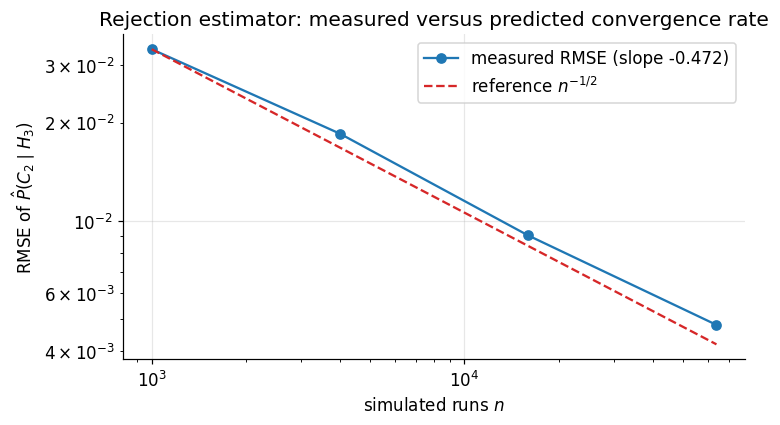

In [7]:
# (b) measured rate: RMSE of the rejection estimator versus predicted n^{-1/2}
def monty_hall(n, rng):
    """Simulate the full mechanism: car placement, contestant pick, host's constrained reveal."""
    car = rng.integers(0, 3, n)
    pick = rng.integers(0, 3, n)
    other = 3 - car - pick                       # the unique third door, used when car != pick
    coin = rng.integers(0, 2, n)
    host_free = np.where(coin == 0, (pick + 1) % 3, (pick + 2) % 3)
    host = np.where(car == pick, host_free, other)
    return car, pick, host

sizes = np.array([1000, 4000, 16000, 64000])
reps = 80
rmse = np.empty(sizes.size)
for k, n in enumerate(sizes):
    err = np.empty(reps)
    for r in range(reps):
        car, pick, host = monty_hall(int(n), rng)
        keep = (pick == 0) & (host == 2)         # condition on the observed event
        err[r] = (car[keep] == 1).mean() - 2/3   # estimate of P(car behind 2 | pick 1, host 3)
    rmse[k] = np.sqrt(np.mean(err**2))

slope = np.polyfit(np.log(sizes), np.log(rmse), 1)[0]
car, pick, host = monty_hall(200_000, rng)
keep = (pick == 0) & (host == 2)
print(f"kept {keep.sum()} of 200000 runs  (predicted fraction 1/6 = {1/6:.4f}, "
      f"observed {keep.mean():.4f})")
print(f"P(car behind 2 | pick 1, host opens 3) ~ {(car[keep] == 1).mean():.4f}   (exact 2/3)")
print(f"P(win | stay) ~ {(car == pick).mean():.4f}   (exact 1/3)")
print(f"RMSE at n = {sizes}: {rmse}")
print(f"measured rate exponent = {slope:.4f}   predicted = -0.5")
assert abs(slope + 0.5) < 0.1

fig, ax = plt.subplots()
ax.loglog(sizes, rmse, "o-", color="tab:blue", label=f"measured RMSE (slope {slope:.3f})")
ax.loglog(sizes, rmse[0] * (sizes / sizes[0]) ** -0.5, "--", color="tab:red",
          label=r"reference $n^{-1/2}$")
ax.set_xlabel("simulated runs $n$")
ax.set_ylabel(r"RMSE of $\hat{P}(C_2 \mid H_3)$")
ax.set_title("Rejection estimator: measured versus predicted convergence rate")
ax.legend()
fig.tight_layout()
plt.show()

The measured exponent is $-0.4721$ against the predicted $-0.5$ — the residual gap is the sampling noise of an RMSE estimated from $80$ replicates, and it shrinks as the replicate count grows — so the rejection estimator converges at the Monte Carlo rate, and the conditional estimate itself lands on $2/3$ while the stay strategy lands on $1/3$ — Example 6.3 confirmed by simulation of the mechanism rather than by argument. Note that only about one run in six survives the filter: when $P(B)$ is small almost all work is discarded, which is precisely the cost that importance sampling, MCMC and variational inference exist to avoid.

### 7.5 The base rate, swept

The final cell sweeps the prevalence with the sensitivity and specificity held fixed, marking the two points computed in Example 6.2.

at prevalence 0.01: sens .95 / spec .90 -> 0.0876; sens = spec = .95 -> 0.1610
prevalence at which the first profile reaches posterior 0.5: 0.0952
perfect sensitivity, specificity 0.90, prevalence 0.01: 0.0917


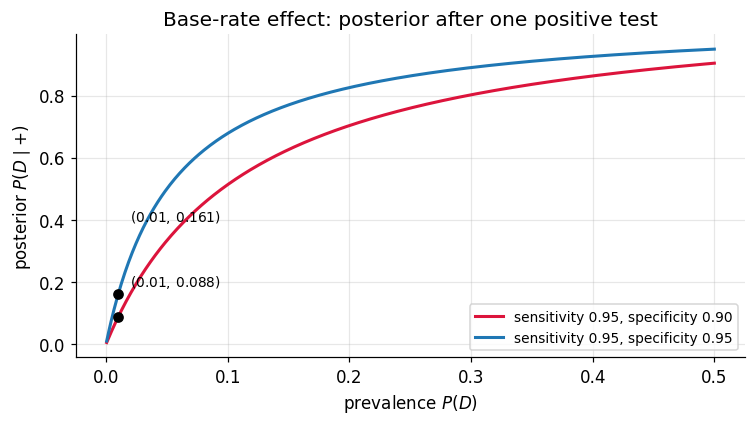

In [8]:
# Posterior P(D | +) as a function of prevalence, for two test profiles.
prevalence = np.linspace(0.0005, 0.5, 500)

def posterior_curve(sens, spec, prev):
    return sens * prev / (sens * prev + (1 - spec) * (1 - prev))

curve_a = posterior_curve(0.95, 0.90, prevalence)   # Example 6.2 profile
curve_b = posterior_curve(0.95, 0.95, prevalence)   # "95% accurate" profile
p0 = 0.01
pt_a = posterior_curve(0.95, 0.90, p0)
pt_b = posterior_curve(0.95, 0.95, p0)
print(f"at prevalence {p0}: sens .95 / spec .90 -> {pt_a:.4f}; sens = spec = .95 -> {pt_b:.4f}")
print(f"prevalence at which the first profile reaches posterior 0.5: "
      f"{(1 - 0.90) / (0.95 + (1 - 0.90)):.4f}")
print(f"perfect sensitivity, specificity 0.90, prevalence {p0}: "
      f"{posterior_curve(1.0, 0.90, p0):.4f}")
assert abs(pt_a - 19/217) < 1e-12 and abs(pt_b - 0.16102) < 1e-5

fig, ax = plt.subplots()
ax.plot(prevalence, curve_a, color="crimson", lw=2, label="sensitivity 0.95, specificity 0.90")
ax.plot(prevalence, curve_b, color="tab:blue", lw=2, label="sensitivity 0.95, specificity 0.95")
ax.scatter([p0, p0], [pt_a, pt_b], color="black", zorder=5)
ax.annotate(f"$({p0},\\,{pt_a:.3f})$", xy=(p0, pt_a), xytext=(0.08, 0.22),
            textcoords="axes fraction", fontsize=9)
ax.annotate(f"$({p0},\\,{pt_b:.3f})$", xy=(p0, pt_b), xytext=(0.08, 0.42),
            textcoords="axes fraction", fontsize=9)
ax.set_xlabel("prevalence $P(D)$")
ax.set_ylabel("posterior $P(D \\mid {+})$")
ax.set_title("Base-rate effect: posterior after one positive test")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

Both curves start near zero and rise steeply: at prevalence $0.01$ the posterior is $0.0876$ for the first profile and $0.1610$ for the second, and the first profile does not reach $0.5$ until the prevalence exceeds $0.0952$. The two curves differ only in specificity, which shows where the leverage lies for rare conditions: halving the false-positive rate from $0.10$ to $0.05$ nearly doubles the posterior, whereas pushing the sensitivity all the way to a perfect $1.0$ moves it only from $0.0876$ to $0.0917$.

## 8. Applications

### 8.1 Machine learning

- **Autoregressive language models.** The chain rule factorization $P(w_{1:T}) = \prod_t P(w_t \mid w_{\lt t})$ of Theorem 4.2 *is* the training objective: next-token cross-entropy is $-\frac{1}{T}\sum_t \log P(w_t \mid w_{\lt t})$, and each softmax head is one conditional distribution.
- **Naive Bayes.** Assume $P(\mathbf{x} \mid y) = \prod_j P(x_j \mid y)$ — features conditionally independent given the class, exactly the structure of Example 6.4's mixture — and Theorem 4.4 turns the per-feature likelihoods into a posterior. In log-odds form (Corollary 4.5) the classifier is linear, which is why it trains in one pass and remains a strong baseline.
- **Classifier evaluation.** Precision is a posterior, $P(\text{positive} \mid \text{flagged})$, while recall is a likelihood, $P(\text{flagged} \mid \text{positive})$. Theorem 4.4 links them through the class prevalence, which is why precision collapses on rare-class problems even at high recall (Problem L2.2).
- **Sequential and streaming inference.** Corollary 4.5 makes yesterday's posterior today's prior with additive log-evidence, so a filter needs $O(1)$ memory per hypothesis; the Kalman filter is this recursion in closed form for linear-Gaussian models.

### 8.2 Bayesian networks and d-separation

A Bayesian network is a directed acyclic graph whose joint distribution factors as $P(x_1, \ldots, x_n) = \prod_i P(x_i \mid \operatorname{pa}(x_i))$ — the chain rule of Theorem 4.2 with each conditioning set pruned to the node's parents. Which conditional independences follow from the graph alone is decided by a purely combinatorial criterion.

**d-separation.** A path between $X$ and $Y$ (ignoring edge directions) is *blocked* by a set $Z$ of nodes if it contains

- a chain $X \to M \to Y$ or $Y \to M \to X$ with $M \in Z$;
- a fork $X \leftarrow M \to Y$ with $M \in Z$; or
- a collider $X \to M \leftarrow Y$ with $M \notin Z$ **and** no descendant of $M$ in $Z$.

$X$ and $Y$ are *d-separated* by $Z$ if every path between them is blocked, in which case $X \perp\!\!\!\perp Y \mid Z$ in every distribution that factors over the graph (Pearl, *Probabilistic Reasoning*, §3.3).

The three two-edge cases are exactly the phenomena of this module. In the chain (a cause acting through a mediator) and the fork (a common cause), conditioning on the middle node *creates* independence: this is why controlling for a confounder works. In the collider, the middle node is a common effect, and conditioning on it *destroys* independence — which is Proposition 4.7, proved in Proof 5.7 and measured in Section 7.3. Selection into a sample is a collider, so selection bias is explaining-away wearing a different hat.

### 8.3 Physics and engineering

- **Statistical mechanics.** The Boltzmann factor is a conditional probability: start from the uniform (microcanonical) measure on joint system-plus-reservoir microstates at fixed total energy and condition on the system's state; the reservoir's entropy expansion turns the count ratio into $e^{-\beta \epsilon}$ and the renormalization into a partition function (Problem L2.5). The softmax layer is the same formula.
- **Tracking and navigation.** Radar and GPS estimators propagate $P(\text{state} \mid \text{measurements so far})$ recursively by Corollary 4.5; the sensor-fusion arithmetic of Problem L2.6 is Bayes factors multiplying under conditional independence.
- **Bayesian data analysis.** Parameter estimation from noisy measurements — for example posteriors over binary-black-hole masses from a gravitational-wave strain series — is Proposition 4.6 with a physical forward model supplying the likelihood.
- **Quantum measurement.** The Lüders update rule assigns post-measurement states that reproduce probabilities conditioned on the observed outcome; it plays the role of Definition 3.1 in a non-commutative probability model.

### 8.4 Formula summary

| Concept | Formula | Typical incarnation |
|---|---|---|
| Conditional probability | $P(A \mid B) = P(A \cap B)/P(B)$ | top-$p$ renormalization, attention masking |
| Chain rule | $P(A_1, \ldots, A_n) = \prod_k P(A_k \mid A_{1:k-1})$ | autoregressive factorization |
| Total probability | $P(A) = \sum_i P(A \mid B_i) P(B_i)$ | marginalizing a latent variable |
| Bayes' theorem | $P(H \mid D) \propto P(D \mid H) P(H)$ | posterior inference, spam filters |
| Odds form | posterior odds $=$ Bayes factor $\times$ prior odds | log-odds accumulation, logistic regression |
| Independence | $P(A \cap B) = P(A) P(B)$ | i.i.d. sampling assumptions |
| Conditional independence | $P(A, B \mid C) = P(A \mid C) P(B \mid C)$ | naive Bayes, graphical models |

## 9. Key Takeaways

- For $P(B) \gt 0$, $A \mapsto P(A \mid B)$ is a probability measure (Theorem 4.1), so every unconditional identity holds verbatim under a fixed conditioning event.
- If $P(A_1 \cap \cdots \cap A_{n-1}) \gt 0$, any joint probability factors into one-step conditionals in any pre-chosen order (Theorem 4.2) — the chain rule behind autoregressive models.
- For a finite or countable partition with $P(B_i) \gt 0$, $P(A)$ is the partition-weighted average of the $P(A \mid B_i)$ (Theorem 4.3); disjointness and exhaustiveness are both load-bearing, as Section 7.3 shows.
- When $P(A) \gt 0$, Bayes' theorem (Theorem 4.4) recovers the posterior from likelihood, prior and evidence; it follows from Definition 3.1 and countable additivity alone, with no extra postulate.
- With $0 \lt P(H) \lt 1$ and $P(D \mid H^c) \gt 0$, posterior odds $=$ Bayes factor $\times$ prior odds (Corollary 4.5), so independent evidence adds in log-odds.
- When the joint density is continuous in $x$ and $f_X(x) \gt 0$, the density form $p(\theta \mid x) \propto p(x \mid \theta) p(\theta)$ is the limit of conditioning on shrinking strips (Proposition 4.6) — a limit, not an analogy, and one that depends on the shrinking family.
- Independence and conditional independence imply each other in neither direction: independent causes become dependent given a common effect (Proposition 4.7), and conditionally independent variables are typically dependent marginally (Example 6.4).
- A high likelihood attached to a low prior yields a low posterior: at prevalence $0.01$, a test with sensitivity $0.95$ and specificity $0.90$ gives $P(D \mid +) = 19/217 \approx 0.0876$ (Example 6.2).

## 10. References

| Source | Chapters / sections | Coverage |
|---|---|---|
| Blitzstein & Hwang, *Introduction to Probability*, 2nd ed. | Ch. 2 (§2.2 definition, §2.3 Bayes, §2.7 Monty Hall) | Conditioning as "the soul of statistics"; paradoxes; first-step analysis. |
| Ross, *A First Course in Probability*, 10th ed. | Ch. 3 (§3.2–3.4) | Conditional probability, Bayes' formula, independence. |
| Casella & Berger, *Statistical Inference*, 2nd ed. | §1.3 (Thm 1.3.5 Bayes), §1.3.4 (independence) | Rigorous statement with hypotheses; independence subtleties. |
| Wasserman, *All of Statistics* | §1.6–1.7 (Thm 1.17, Bayes) | Compact measure-theoretic-flavoured treatment. |
| Bishop, *Pattern Recognition and Machine Learning* | §1.2 (sum and product rules), §8.2 (d-separation) | Bayes for ML; graphical conditional independence. |
| Murphy, *Probabilistic Machine Learning: An Introduction* | Ch. 2 (§2.1–2.3), §4.2 | Base rates, naive Bayes, sequential updating. |
| Pearl, *Probabilistic Reasoning in Intelligent Systems* | §1.2, §3.3 (d-separation) | Bayesian networks, explaining away, collider bias. |
| Kolmogorov, *Foundations of the Theory of Probability* | Ch. V (conditional probabilities and expectations) | Conditioning on null events; the partition-dependence resolution. |
| Jaynes, *Probability Theory: The Logic of Science* | Ch. 1–2 (Cox's theorem), Ch. 15 (paradoxes) | Probability as extended logic; Borel-type paradoxes. |

**Reading path.** Blitzstein & Hwang Ch. 2 for intuition and paradoxes, Casella & Berger §1.3 for the statements with hypotheses attached, then Bishop §8.2 and Pearl §3.3 for the graphical view that scales conditioning to thousands of variables. For the null-event subtleties behind Proposition 4.6 and Problem L3.3, Kolmogorov Ch. V is still the clearest short source.